# Managing sequencing files

I'm starting off with a bit of a mess. There were unfortunately two versions of sequencing used, meaning that the basecalling algorithms have to be different.  

Sequencing done on or after **Tuesday 19th December 2023** should all be pod5 original files, and used for code development.  

Prior to this date, sequencing was originally done to fast5 output and used a slightly different version of sequencing. Use these files with caution, and only for testing biological output (i.e. immune infiltrate prediction), ensuring that the bam files match appropriately.  

#### Checking out info about the pod5s I'm using

In [18]:
import os
import pod5 as p5

In [ ]:
path2dir = "/external/data/lucy/panorama/231221_l_picard/20231219-LPFT/20231219_1156_P2S-00751-A_PAK79113_5aec4148/pod5"

files = os.listdir(path2dir)


In [25]:
for f in files:
    path_to_file = os.path.join(path2dir, f)
    
    with p5.Reader(path_to_file) as reader:
        for read in reader:
            selected_read_id = read.read_id
            selected_read_run_info = read.run_info
            break
        print(f"Selected read ID: {selected_read_id}")
        # print(f"Selected read run_info: {selected_read_run_info}")
        print(f"Selected read protocol_start_time: {selected_read_run_info.protocol_start_time}")
        print(f"Selected read system_type: {selected_read_run_info.system_type}")
        print(f"Selected read protocol_name: {selected_read_run_info.protocol_name}")
    
    break

Selected read ID: 5b3874b6-edc6-403a-b68d-423bdabec235
Selected read protocol_start_time: 2023-12-18 22:56:30.521000+00:00
Selected read system_type: GridION Mk1
Selected read protocol_name: sequencing/sequencing_PRO114_DNA_e8_2_400K:FLO-PRO114M:SQK-LSK114:400


In [20]:
import matplotlib.pyplot as plt
import numpy as np

Selected read ID: 5b3874b6-edc6-403a-b68d-423bdabec235


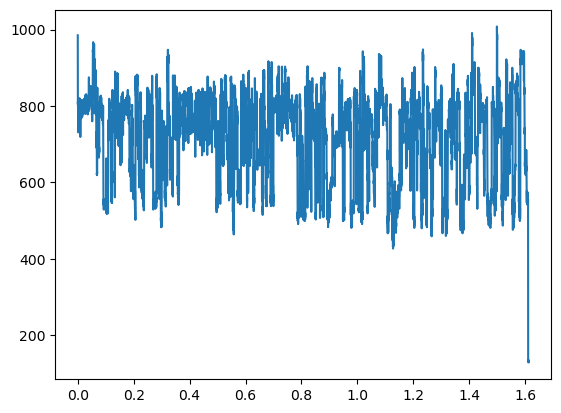

In [21]:
with p5.Reader(path_to_file) as reader:
    for read in reader:
        selected_read_id = read.read_id
        break
    print(f"Selected read ID: {selected_read_id}")

    # Read the selected read from the pod5 file
    # next() is required here as Reader.reads() returns a Generator
    read = next(reader.reads([selected_read_id]))

    # Get the signal data and sample rate
    sample_rate = read.run_info.sample_rate
    signal = read.signal

    # Compute the time steps over the sampling period
    time = np.arange(len(signal)) / sample_rate

    # Plot using matplotlib
    plt.plot(time, signal)

### Thu 06 Nov 2025
Wrote and run `cleanup.sh` to begin managing the mess.  
Ideally I want to end up with one folder for fast5s and one folder for pod5s.  
Though this hasn't been working great for dorado on BEBIC so far, so I don't know that it will be any better.  